# Cohort Analysis

You can find the full lecture [here](https://hovhannisyan91.github.io/aca/materials/python/session11.html)


## Importing Packages

In [1]:
import pandas as pd
from scipy import stats
import plotly.express as px
from utils import csv_downloader


## Loading and Observing the data

In [7]:
df = pd.read_csv('../data/cohort/cohort_analysis.csv',
                 parse_dates = ['acquisition_date','cancellation_month'])
df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic


In [8]:
df.shape

(12000, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             12000 non-null  int64         
 1   acquisition_date    12000 non-null  datetime64[us]
 2   cancellation_month  7066 non-null   datetime64[us]
 3   gender              12000 non-null  str           
 4   marital_status      12000 non-null  str           
 5   age                 12000 non-null  int64         
 6   income_segment      11369 non-null  str           
 7   country             12000 non-null  str           
 8   channel             12000 non-null  str           
 9   campaign_id         12000 non-null  str           
 10  device_type         12000 non-null  str           
 11  plan_type           12000 non-null  str           
dtypes: datetime64[us](2), int64(2), str(8)
memory usage: 1.7 MB


In [ ]:
# Missing values:
df.isnull().sum()



user_id                  0
acquisition_date         0
cancellation_month    4934
gender                   0
marital_status           0
age                      0
income_segment         631
country                  0
channel                  0
campaign_id              0
device_type              0
plan_type                0
dtype: int64

In [6]:
df.describe()

,user_id,acquisition_date,cancellation_month,age
count,12000.00000,12000,7066,12000.000000
mean,6000.50000,2024-04-15 20:46:48,2024-07-28 15:31:07.761109,34.630250
min,1.00000,2024-01-01 00:00:00,2024-02-01 00:00:00,18.000000
25%,3000.75000,2024-02-01 00:00:00,2024-05-01 00:00:00,28.000000
50%,6000.50000,2024-04-01 00:00:00,2024-07-01 00:00:00,34.000000
75%,9000.25000,2024-06-01 00:00:00,2024-10-01 00:00:00,41.000000
max,12000.00000,2024-08-01 00:00:00,2025-08-01 00:00:00,65.000000
std,3464.24595,NaN,NaN,9.514896


## Derived Columns and Exploration

In this section we are going to create all the necessary columns/features which will help us to eventually create cohorts

In [11]:
df["acquisition_month"] = df["acquisition_date"].dt.to_period("M")

## Visualizing

<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

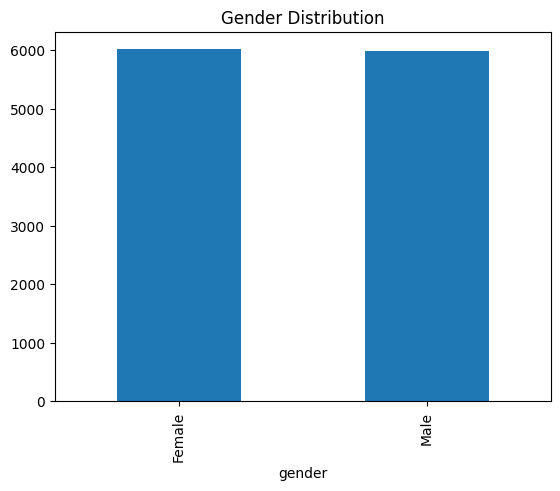

In [14]:
df["gender"].value_counts().plot(kind="bar", title="Gender Distribution")

<Axes: title={'center': 'Marital Status Distribution'}, xlabel='marital_status'>

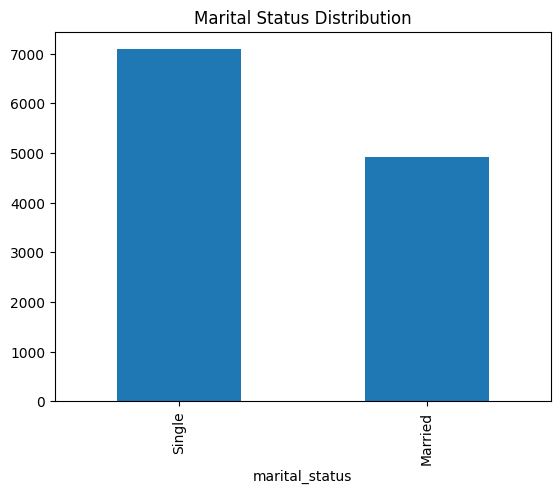

In [15]:
df["marital_status"].value_counts().plot(kind="bar", title="Marital Status Distribution")

<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

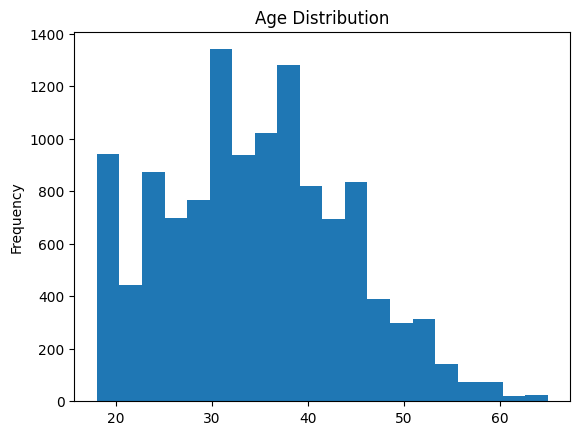

In [16]:
df["age"].plot(kind="hist", bins=20, title="Age Distribution")

<Axes: title={'center': 'Country Distribution'}, xlabel='country'>

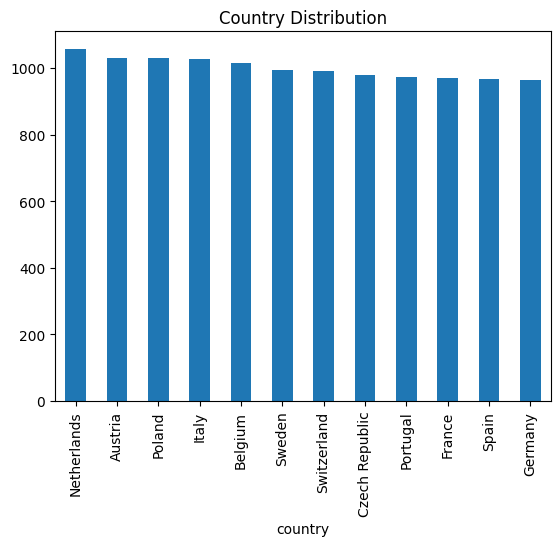

In [17]:
df["country"].value_counts().plot(kind="bar", title="Country Distribution")

<Axes: title={'center': 'Channel Distribution'}, xlabel='channel'>

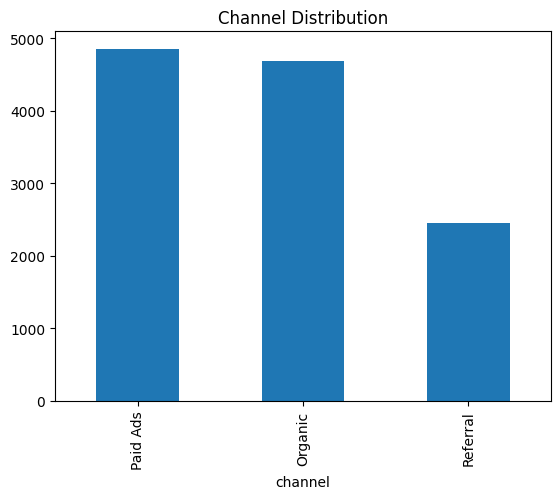

In [18]:
df["channel"].value_counts().plot(kind="bar", title="Channel Distribution")

<Axes: title={'center': 'Plan Type Distribution'}, xlabel='plan_type'>

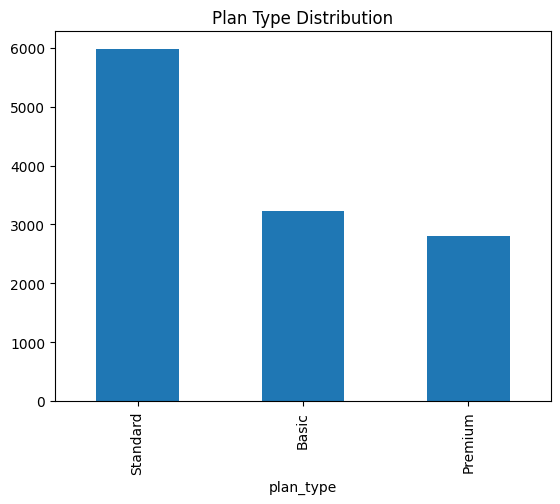

In [19]:
df["plan_type"].value_counts().plot(kind="bar", title="Plan Type Distribution")

## Cohortwise Analysis

In [20]:
cohort_size = df.groupby("acquisition_month")["user_id"].nunique()
cohort_size

acquisition_month
2024-01    1502
2024-02    1528
2024-03    1465
2024-04    1509
2024-05    1541
2024-06    1493
2024-07    1500
2024-08    1462
Freq: M, Name: user_id, dtype: int64

In [21]:
cohort_size = df.groupby("acquisition_month")["user_id"].size()
cohort_size

acquisition_month
2024-01    1502
2024-02    1528
2024-03    1465
2024-04    1509
2024-05    1541
2024-06    1493
2024-07    1500
2024-08    1462
Freq: M, Name: user_id, dtype: int64

<Axes: title={'center': 'Cohort Size by Acquisition Month'}, xlabel='acquisition_month'>

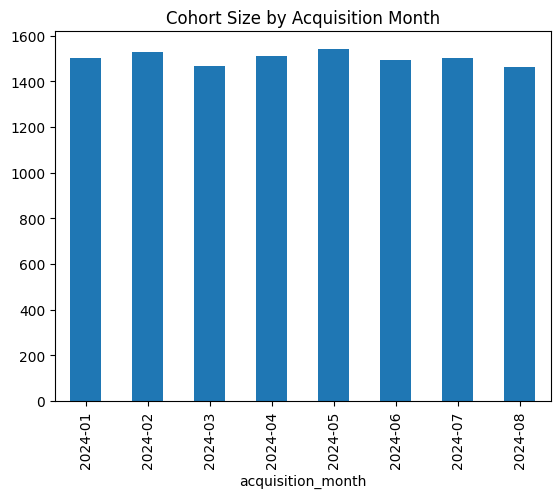

In [23]:
cohort_size.plot(kind="bar", 
                 title="Cohort Size by Acquisition Month")

In [25]:
gender_cohort.head()

gender,Female,Male
acquisition_month,,
2024-01,734,768
2024-02,798,730
2024-03,729,736
2024-04,749,760
2024-05,798,743


<Axes: title={'center': 'Gender Composition by Cohort'}, xlabel='acquisition_month'>

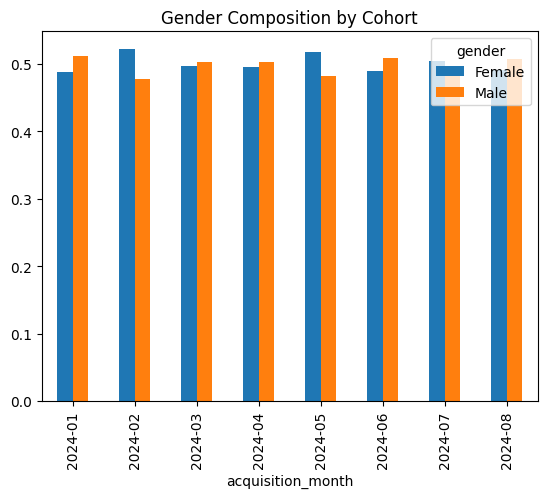

In [24]:
gender_cohort = (
    df.groupby(["acquisition_month", "gender"])["user_id"]
    .nunique()
    .unstack()
)

gender_cohort.div(gender_cohort.sum(axis=1), axis=0).plot(
    kind="bar",
    stacked=False,
    title="Gender Composition by Cohort"
)


<Axes: title={'center': 'Channel Composition by Cohort'}, xlabel='acquisition_month'>

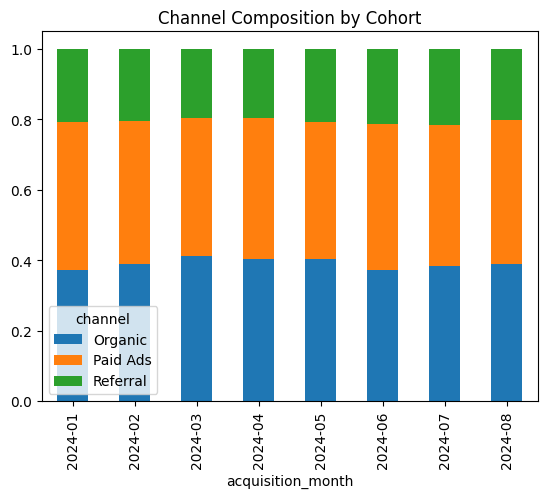

In [26]:
# Channel by cohort
channel_cohort = (
    df.groupby(["acquisition_month", "channel"])["user_id"]
    .nunique()
    .unstack()
)

channel_cohort.div(channel_cohort.sum(axis=1), axis=0).plot(
    kind="bar",
    stacked=True,
    title="Channel Composition by Cohort"
)

<Axes: title={'center': 'Plan Type Composition by Cohort'}, xlabel='acquisition_month'>

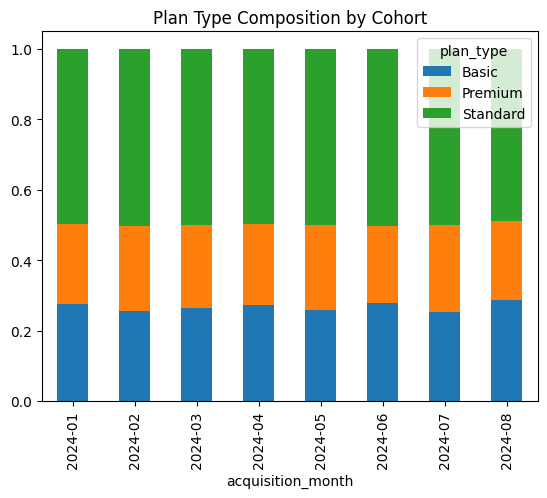

In [27]:

# Plan type by cohort
plan_cohort = (
    df.groupby(["acquisition_month", "plan_type"])["user_id"]
    .nunique()
    .unstack()
)

plan_cohort.div(plan_cohort.sum(axis=1), axis=0).plot(
    kind="bar",
    stacked=True,
    title="Plan Type Composition by Cohort"
)

## Cohort Analysis Data Prep

### Month Churned

In [33]:
df[['user_id',	'acquisition_date', 'acquisition_month',	'cancellation_month']].head()

,user_id,acquisition_date,acquisition_month,cancellation_month
0,1,2024-07-01,2024-07,2025-02-01
1,2,2024-04-01,2024-04,2024-05-01
2,3,2024-05-01,2024-05,2024-07-01
3,4,2024-07-01,2024-07,NaT
4,5,2024-03-01,2024-03,2024-04-01


In [10]:
# calculating the month_churned
df["month_churned"] =(
    (df["cancellation_month"].dt.year - df["acquisition_month"].dt.year) * 12 +
    (df["cancellation_month"].dt.month - df["acquisition_month"].dt.month)
)
df['month_churned'].value_counts()


month_churned
1.0     2392
2.0     1363
3.0      845
4.0      585
5.0      443
6.0      362
7.0      266
8.0      248
9.0      182
10.0     168
11.0     113
12.0      99
Name: count, dtype: int64

In [11]:
df['month_churned'].value_counts().loc[12]

np.int64(99)

In [12]:
df["month_churned"] = df["month_churned"].fillna(12)

df['month_churned'].value_counts().loc[12]

np.int64(5033)

In [13]:
df["month_churned"] = df["month_churned"].clip(lower=0, upper=12)
df['month_churned'].value_counts()

month_churned
12.0    5033
1.0     2392
2.0     1363
3.0      845
4.0      585
5.0      443
6.0      362
7.0      266
8.0      248
9.0      182
10.0     168
11.0     113
Name: count, dtype: int64

In [14]:
df['month_churned'].value_counts().loc[12]

np.int64(5033)

### Cohort Data

In [15]:

cohort_data = (
    df.groupby(["acquisition_month", "month_churned"])
      .agg(users=("user_id", "count"))
      .reset_index()
)

# Sort correctly
cohort_data = cohort_data.sort_values(["acquisition_month", "month_churned"])

cohort_data.head()

,acquisition_month,month_churned,users
0,2024-01,1.0,148
1,2024-01,2.0,95
2,2024-01,3.0,79
3,2024-01,4.0,76
4,2024-01,5.0,52


In [16]:

cohort_size= (
    df.groupby(["acquisition_month"])
      .agg(new_users=("user_id", "count"))
      .reset_index()
)
cohort_size.head()

,acquisition_month,new_users
0,2024-01,1502
1,2024-02,1528
2,2024-03,1465
3,2024-04,1509
4,2024-05,1541


In [17]:
## now meened to merge: ATTENTION its a selfjoin

cohort_data = cohort_data.merge(cohort_size, on="acquisition_month")

cohort_data.head()

,acquisition_month,month_churned,users,new_users
0,2024-01,1.0,148,1502
1,2024-01,2.0,95,1502
2,2024-01,3.0,79,1502
3,2024-01,4.0,76,1502
4,2024-01,5.0,52,1502


In [18]:
cohort_data["cumulative_churn"] = (
    cohort_data
    .groupby("acquisition_month")["users"]
    .cumsum()
)
cohort_data.head()

,acquisition_month,month_churned,users,new_users,cumulative_churn
0,2024-01,1.0,148,1502,148
1,2024-01,2.0,95,1502,243
2,2024-01,3.0,79,1502,322
3,2024-01,4.0,76,1502,398
4,2024-01,5.0,52,1502,450


In [19]:
# ------------------------------------------
# 1. Create full tenure grid (VERY IMPORTANT)
# ------------------------------------------
import numpy as np

max_month = 12
tenure_range = np.arange(1, max_month + 1)

full_index = pd.MultiIndex.from_product(
    [
        cohort_data["acquisition_month"].unique(),
        tenure_range
    ],
    names=["acquisition_month", "month_churned"]
)

cohort_data = (
    cohort_data
    .set_index(["acquisition_month", "month_churned"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# ------------------------------------------
# 2. Recalculate cumulative churn (now correct)
# ------------------------------------------
cohort_data = cohort_data.sort_values(["acquisition_month", "month_churned"])

cohort_data["cumulative_churn"] = (
    cohort_data
    .groupby("acquisition_month")["users"]
    .cumsum()
)

# ------------------------------------------
# 3. Calculate active users
# ------------------------------------------
cohort_data["active_users"] = (
    cohort_data["new_users"] - cohort_data["cumulative_churn"]
)

# ------------------------------------------
# 4. Retention rate
# ------------------------------------------
cohort_data["retention_rate"] = (
    cohort_data["active_users"] / cohort_data["new_users"]
)

cohort_data["acquisition_month"] = cohort_data["acquisition_month"].astype(str)
# ------------------------------------------
# 5. Pivot for heatmap
# ------------------------------------------
heatmap_data = cohort_data.pivot(
    index="acquisition_month",
    columns="month_churned",
    values="retention_rate"
)

# ------------------------------------------
# 6. Plot heatmap
# ------------------------------------------
fig = px.imshow(
    heatmap_data,
    aspect="auto",
    color_continuous_scale="Blues",
    labels=dict(color="Retention Rate")
)

fig.update_layout(
    title="Cohort Retention Heatmap",
    xaxis_title="Months Since Acquisition",
    yaxis_title="Acquisition Month"
)

fig.show()

In [20]:
heatmap_data

month_churned,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
acquisition_month,,,,,,,,,,,,
2024-01,0.901465,0.838216,0.785619,0.735020,0.700399,0.667776,0.640479,0.615846,0.599867,0.582557,0.575233,0.0
2024-02,0.898560,0.826571,0.767670,0.726440,0.685864,0.649869,0.628272,0.607330,0.587042,0.569372,0.553010,0.0
2024-03,0.651195,0.494198,0.423208,0.379522,0.345392,0.325597,0.305802,0.291468,0.283959,0.273038,0.270307,0.0
2024-04,0.644798,0.487078,0.408880,0.370444,0.341948,0.322068,0.308151,0.298211,0.287608,0.280318,0.273691,0.0
2024-05,0.755354,0.603504,0.522388,0.467229,0.420506,0.384166,0.363400,0.345230,0.328358,0.315380,0.305646,0.0
2024-06,0.744139,0.582050,0.473543,0.409243,0.373074,0.344943,0.318151,0.299397,0.287341,0.270596,0.260549,0.0
2024-07,0.905333,0.823333,0.773333,0.722000,0.688000,0.651333,0.627333,0.596000,0.580000,0.561333,0.550667,0.0
2024-08,0.903557,0.841313,0.778386,0.733242,0.692886,0.661423,0.638167,0.610807,0.588919,0.578659,0.567031,0.0


In [1]:
cohort_data

NameError: name 'cohort_data' is not defined

## By GPT

In [2]:

df = pd.read_csv('../data/cohort/cohort_analysis.csv',
                 parse_dates=['acquisition_date','cancellation_month'])

# Monthly cohort
df["acquisition_month"] = df["acquisition_date"].dt.to_period("M").dt.to_timestamp()

df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type,acquisition_month
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard,2024-07-01
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard,2024-04-01
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard,2024-05-01
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard,2024-07-01
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic,2024-03-01


In [3]:
cohort_size = (
    df.groupby("acquisition_month")
      .agg(new_users=("user_id", "count"))
      .reset_index()
)

cohort_size


,acquisition_month,new_users
0,2024-01-01,1502
1,2024-02-01,1528
2,2024-03-01,1465
3,2024-04-01,1509
4,2024-05-01,1541
5,2024-06-01,1493
6,2024-07-01,1500
7,2024-08-01,1462


In [7]:
from utils import my_date_diff
df = my_date_diff(df=df,
                  target_column='month_churned',
                  start_date='acquisition_month',
                  end_date='cancellation_month'
                  )

df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type,acquisition_month,month_churned
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard,2024-07-01,7.0
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard,2024-04-01,1.0
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard,2024-05-01,2.0
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard,2024-07-01,NaN
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic,2024-03-01,1.0
